## Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import r2_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold

from scipy import stats
from scipy.signal import decimate

import torch
from torch.utils.data import DataLoader, random_split, TensorDataset

from models.ctae import CoupledTransformerAutoencoderTwoRegions

from pathlib import Path
from utils import safe_format, pred_normalize, get_cv_score_acc, create_data_loaders



## Configuration and Paths

In [2]:
bin_size = 0.1
sigma = 1
preGoCue = 1
postGoCue = 2


r1_specific_dim = 10
r2_specific_dim = 10
shared_latent_dim = 10

nhead = 1
num_layers = 3

learning_rate = 1e-4

lambda_ortho = 1e-3
lambda_alignment = 0.5
lambda_recons2 = 1
lambda_shared = 1

warm_up_ortho = 100
pe = True
pe_learn = False
max_len = 50

batch_size = 400
num_epochs = 5000

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')


In [3]:
# ------------------------
# File paths
# ------------------------
DATA_ROOT = "./data"
PROCESSED_DIR = f"{DATA_ROOT}/processed"

nwb_file = "sub-M_ses-CO-20140303_behavior+ecephys.nwb"
dataset_name = Path(nwb_file).stem

config_name = f"binsize{int(bin_size*1000)}ms_sigma{int(bin_size*sigma*1000)}ms_pre{preGoCue}_post{postGoCue}"
processed_folder = f"{PROCESSED_DIR}/{dataset_name}/{config_name}"

DATA1_PATH = f"{processed_folder}/M1_rates.npy"
DATA2_PATH = f"{processed_folder}/PMd_rates.npy"
CONDITION_PATH = f"{processed_folder}/condition.npy"
POSITION_PATH = f"{processed_folder}/position.npy"
TRIAL_TIMES_PATH = f"{processed_folder}/trial_times.npy"


TRAINED_MODELS_ROOT = "./trained_models"
model_path = (
    f"{TRAINED_MODELS_ROOT}/ctae"
    f"_bs{batch_size}"
    f"_lr{safe_format(learning_rate)}"
    f"_L{num_layers}"
    f"_r1-{r1_specific_dim}_r2-{r2_specific_dim}"
    f"_s{shared_latent_dim}"
    f"_pe{'T' if pe else 'F'}"
    f"_align{lambda_alignment}"
    f"_ortho{safe_format(lambda_ortho)}"
    f"_recons2-{lambda_recons2}"
    f"_shared-{lambda_shared}"
    f"_warm{warm_up_ortho}"
    f"_ep{num_epochs}.pth"
)



## Load Neural and Behavioral Data

In [4]:
data1 = np.load(DATA1_PATH)
data2 = np.load(DATA2_PATH)
condition = np.load(CONDITION_PATH)
position = np.load(POSITION_PATH)
trial_times = np.load(TRIAL_TIMES_PATH)

condition = np.delete(condition, 4, axis=0)
data1 = np.delete(data1, 4, axis=1)
data2 = np.delete(data2, 4, axis=1)
position = np.delete(position, 4, axis=0)

data1_zscored = stats.zscore(data1.reshape(data1.shape[0],-1),axis=-1).reshape(data1.shape)
data2_zscored = stats.zscore(data2.reshape(data2.shape[0],-1),axis=-1).reshape(data2.shape)

data1 = data1.transpose(1,2,0)
data2 = data2.transpose(1,2,0)
data1_zscored = data1_zscored.transpose(1,2,0)
data2_zscored = data2_zscored.transpose(1,2,0)

data1 = data1_zscored
data2 = data2_zscored
# (1000, 500, 50)
data = np.concatenate((data1, data2), axis=-1)

time = np.arange(data.shape[1])*bin_size


input_dim1 = data1.shape[-1] # Input dimension (feature size)
input_dim2 = data2.shape[-1]


## Load Trained Model 

In [ ]:
# Create the model
model = CoupledTransformerAutoencoderTwoRegions(input_dim1, input_dim2, r1_specific_dim, r2_specific_dim, shared_latent_dim, nhead, num_layers, num_layers, max_len, pe, pe_learn)
model = model.to(device)

# Load trained model
model.load_state_dict(torch.load(model_path, map_location=device))

model.eval()


## Prepare Data Loaders

In [6]:

data_tensor = torch.tensor(data, dtype=torch.float32)
y = torch.tensor(condition[:, 0:1], dtype=torch.float32)
data_tensor = TensorDataset(data_tensor, y)

full_data_loader = DataLoader(data_tensor, batch_size=batch_size, shuffle=False)

train_dataloader_pred, val_dataloader_pred, test_dataloader_pred = create_data_loaders(data, batch_size=batch_size, y=condition[:, 0:1],y_pos=position)


## Extract Shared and Region-Specific Latent Representations

/tmp/ipykernel_76338/85635798.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap       = cm.get_cmap('hsv', n_levels)  # cyclic: 0-7 wrap smoothly


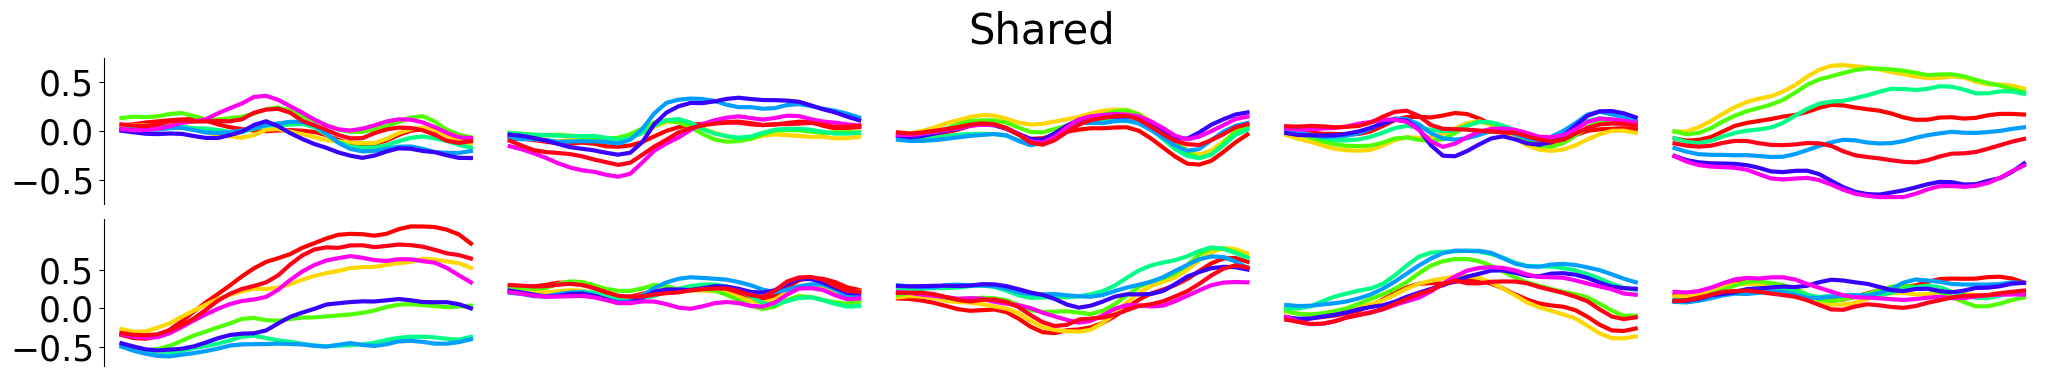

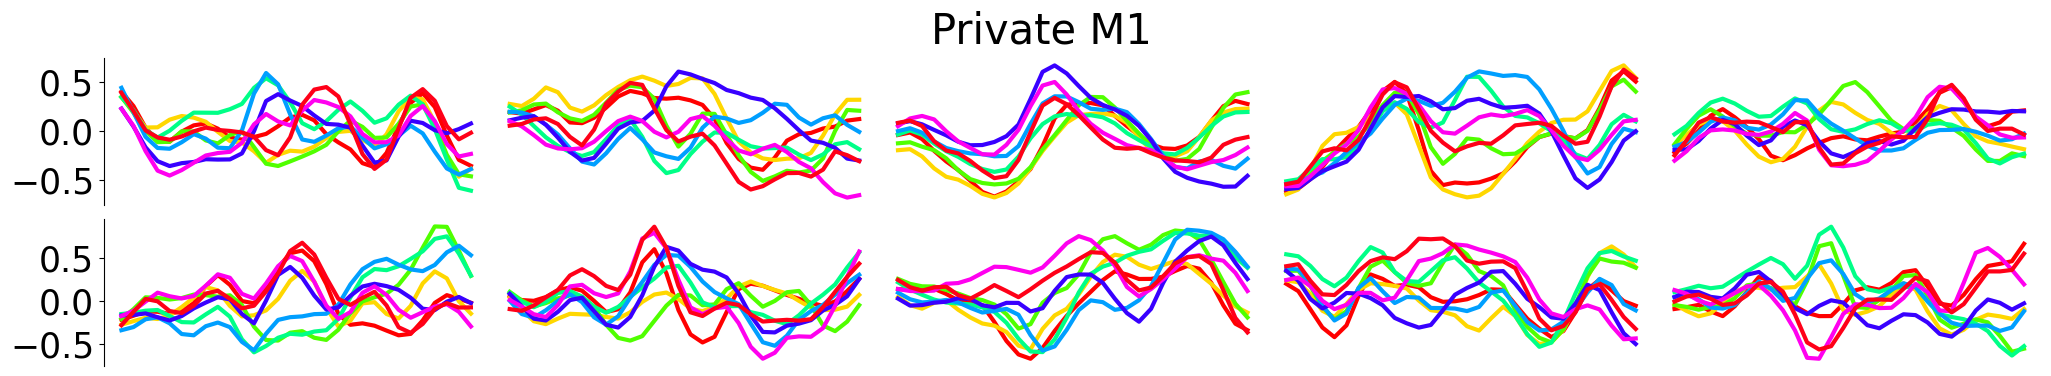

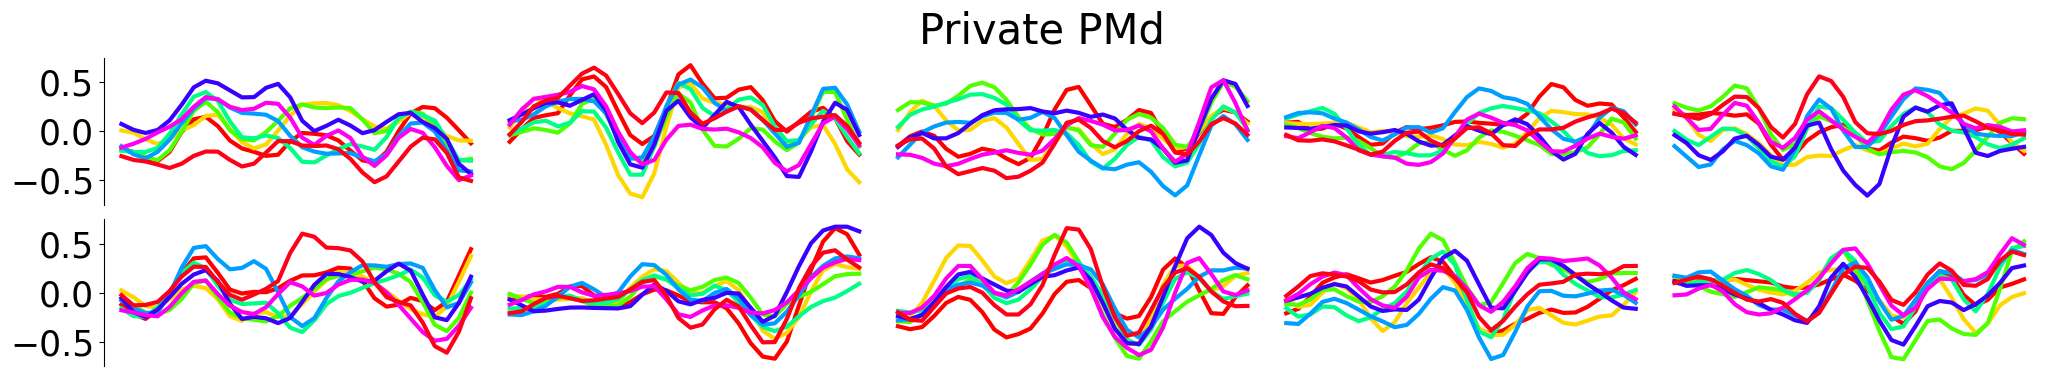

In [7]:

import matplotlib.cm as cm
for data_name in ["shared","region_specific_m1","region_specific_pmd"]:
    model.eval()
    
    with torch.no_grad():
        for data_cur, condition in full_data_loader:
            data_cur = data_cur.float().to(device)
            x11_hat, x22_hat, x12_hat, x21_hat, shared_subspace1, shared_subspace2, specific_subspace1,specific_subspace2,_ = model(data_cur, num_neurons1=input_dim1)
            data_latent_shared = (shared_subspace1+shared_subspace2)/2

    if data_name=="shared":
        data_latent = data_latent_shared#data_latent_specific1#data_latent_shared
        region = "Shared"
        latent_order = [1,2,3,4,5,10]
    elif data_name=="region_specific_m1":
        data_latent = specific_subspace1
        region = "Private M1"
        latent_order = [2,3,5,7 ]
    elif data_name=="region_specific_pmd":
        data_latent = specific_subspace2
        region = "Private PMd"
        latent_order = [1,5]

    data_latent = data_latent.detach().cpu().numpy().transpose(1,0,2)
    conditions = condition.detach().cpu().numpy()

    n_trials, n_times, n_latent = data_latent.shape

    n_cols = 5
    n_rows = 2 #math.ceil(n_latent/n_cols) 

    plt.figure(figsize=(5*n_cols,2*n_rows))
    
    n_levels   = 8                          # conditions are 0 … 7
    cmap       = cm.get_cmap('hsv', n_levels)  # cyclic: 0-7 wrap smoothly
    norm_cond  = condition % n_levels       # just in case values go past 7
    
    new_full_order = latent_order + list(set(np.arange(1,n_latent+1))-set(latent_order))
    new_full_order = np.array(new_full_order)-1
    
    for plot_idx,latent_dim in enumerate(new_full_order):
    #     plt.subplot(n_rows,n_cols,latent_dim+1)
        plt.subplot(n_rows,n_cols,plot_idx+1)
        for cond in range(8):
            color = cmap(cond / n_levels)
            
            times = np.arange(n_times)/10
            
            trials_cond = (conditions==cond).flatten()
            plt.plot(np.mean(data_latent[trials_cond,:,latent_dim],axis=0),linewidth=3,color=color)

            ymin,ymax=plt.ylim()
    
        lim = 0.75
        ymin = min([-lim,ymin*1.01])
        ymax = max([lim,ymax*1.01])
        
        plt.ylim([ymin,ymax])
            
        if plot_idx in [0,5]:
            plt.yticks([-0.5,0,0.5],fontsize=25)
            plt.xticks([0,10])
            
            plt.gca().spines[['right', 'top','bottom']].set_visible(False)
            plt.gca().xaxis.set_visible(False)


        else:
            plt.axis("off")
            
    plt.suptitle(f"{region}",fontsize=30,y=1.0)
    plt.subplots_adjust(wspace=0.01,hspace=0.1)

    plt.show()


## Decode Position and Target direction from Latents

In [ ]:

reconstruction_dict = {}

for data_name in ["shared","region_specific_m1","region_specific_pmd","shared+m1","shared+pmd","data1","data2"]: #,"region_specific_m1","region_specific_pmd"
    reconstruction_dict[data_name] = {}
    print(f"=========== {data_name} ============")
    decode = "position"

        
    print(f"------- {decode} -------")
        
    model.eval()
    with torch.no_grad():
        for data_cur, condition, pos in train_dataloader_pred:
            data_cur = data_cur.float().to(device)
            x11_hat, x22_hat, x12_hat, x21_hat, shared_subspace1, shared_subspace2, specific_subspace1,specific_subspace2,_ = model(data_cur, num_neurons1=input_dim1)
            data_latent_shared = (shared_subspace1+shared_subspace2)/2
            x1, x2 = model.split_data(data_cur, num_neurons1=input_dim1)

    if data_name=="shared":
        data_latent = data_latent_shared#data_latent_specific1#data_latent_shared
    elif data_name=="region_specific_m1":
        data_latent = specific_subspace1
    elif data_name=="region_specific_pmd":
        data_latent = specific_subspace2
    elif data_name=="data1":
        data_latent = x1
    elif data_name=="data2":
        data_latent = x2
    elif data_name=="shared+m1":
        data_latent = torch.concatenate([data_latent_shared,specific_subspace1],axis=-1)
    elif data_name=="shared+pmd":
        data_latent = torch.concatenate([data_latent_shared,specific_subspace2],axis=-1)


    data_latent_train = data_latent.detach().cpu().numpy()
    condition_train = condition.detach().cpu().numpy()
    pos = pos.detach().cpu().numpy()
    
    pos = pred_normalize(pos)
    


    X_train = data_latent_train.transpose(1,0,2)


    if decode=="position":
        y_train = decimate(pos, 10, axis=1, ftype='fir', zero_phase=True) #pos_test[:,::10,:]
    if decode=="velocity":
        y_train = decimate(vel, 10, axis=1, ftype='fir', zero_phase=True) #vel_test[:,::10,:]
    if decode=="acceleration":
        y_train = decimate(acc, 10, axis=1, ftype='fir', zero_phase=True) #acc_test[:,::10,:]



    with torch.no_grad():
        for data_cur, condition, pos in val_dataloader_pred:
            data_cur = data_cur.float().to(device)
            x11_hat, x22_hat, x12_hat, x21_hat, shared_subspace1, shared_subspace2, specific_subspace1,specific_subspace2,_ = model(data_cur, num_neurons1=input_dim1)
            data_latent_shared = (shared_subspace1+shared_subspace2)/2
            x1, x2 = model.split_data(data_cur, num_neurons1=input_dim1)

    if data_name=="shared":
        data_latent = data_latent_shared#data_latent_specific1#data_latent_shared
    elif data_name=="region_specific_m1":
        data_latent = specific_subspace1
    elif data_name=="region_specific_pmd":
        data_latent = specific_subspace2
    elif data_name=="data1":
        data_latent = x1
    elif data_name=="data2":
        data_latent = x2
    elif data_name=="shared+m1":
        data_latent = torch.concatenate([data_latent_shared,specific_subspace1],axis=-1)
    elif data_name=="shared+pmd":
        data_latent = torch.concatenate([data_latent_shared,specific_subspace2],axis=-1)


    data_latent_val = data_latent.detach().cpu().numpy()
    condition_val = condition.detach().cpu().numpy()
    pos_val = pos.detach().cpu().numpy()
    pos_val = pred_normalize(pos_val)
    X_val = data_latent_val.transpose(1,0,2)


    if decode=="position":
        y_val = decimate(pos_val, 10, axis=1, ftype='fir', zero_phase=True) #pos_test[:,::10,:]

    with torch.no_grad():
        for data_cur, condition, pos in test_dataloader_pred:
            data_cur = data_cur.float().to(device)
            x11_hat, x22_hat, x12_hat, x21_hat, shared_subspace1, shared_subspace2, specific_subspace1,specific_subspace2,_ = model(data_cur, num_neurons1=input_dim1)
            data_latent_shared = (shared_subspace1+shared_subspace2)/2
            x1, x2 = model.split_data(data_cur, num_neurons1=input_dim1)

    if data_name=="shared":
        data_latent = data_latent_shared#data_latent_specific1#data_latent_shared
    elif data_name=="region_specific_m1":
        data_latent = specific_subspace1
    elif data_name=="region_specific_pmd":
        data_latent = specific_subspace2
    elif data_name=="data1":
        data_latent = x1
    elif data_name=="data2":
        data_latent = x2
    elif data_name=="shared+m1":
        data_latent = torch.concatenate([data_latent_shared,specific_subspace1],axis=-1)
    elif data_name=="shared+pmd":
        data_latent = torch.concatenate([data_latent_shared,specific_subspace2],axis=-1)


    data_latent_test = data_latent.detach().cpu().numpy()
    condition_test = condition.detach().cpu().numpy()
    pos_test = pos.detach().cpu().numpy()
    
    pos_test = pred_normalize(pos_test)
    X_test = data_latent_test.transpose(1,0,2)
    y_test = decimate(pos_test, 10, axis=1, ftype='fir', zero_phase=True) #pos_test[:,::10,:]

    X = np.vstack([X_train,X_val,X_test])
    Y = np.vstack([y_train,y_val,y_test])
    conditions = np.vstack([condition_train,condition_val,condition_test])
    X = X[:,10:,:]
    Y = Y[:,10:]


    n_trials, n_times, n_latent = X.shape
    _, _, n_pred = Y.shape

    # 1) Flatten trials and time into samples
    X_flat = X.reshape(n_trials * n_times, n_latent)
    Y_flat = Y.reshape(n_trials * n_times, n_pred)

    # 2) Fit multi-output linear regression
    model_linear_reg = LinearRegression()
    model_linear_reg.fit(X_flat, Y_flat)

    # 3) Predict on the same data (or new data shaped the same way)
    Y_pred_flat = model_linear_reg.predict(X_flat)

    # 4) Compute R²
    #    – Overall R² (uniform average across the 2 outputs)
    r2_overall    = r2_score(Y_flat, Y_pred_flat, multioutput='uniform_average')
    #    – R² separately for each output dimension
    r2_per_output = r2_score(Y_flat, Y_pred_flat, multioutput='raw_values')

    print(f"Overall R²: {r2_overall:.3f}")
    print(f"R² per output: {r2_per_output}")

    # 5) reshape predictions back to (n_trials, n_times, n_pred)
    Y_pred = Y_pred_flat.reshape(n_trials, n_times, n_pred)

    # 1) Compute an R² for each trial (flattening time & output dims)
    trial_r2 = np.zeros(n_trials)
    for i in range(n_trials):
        y_true = Y[i].reshape(-1)
        y_pred = Y_pred[i].reshape(-1)
        trial_r2[i] = r2_score(y_true, y_pred)

    conds_flat = np.repeat(conditions, n_times) 
    Y_flat      = Y.reshape(-1, 2)
    Yp_flat     = Y_pred.reshape(-1, 2)

    reconstruction_dict[data_name][decode] = {}
    reconstruction_dict[data_name][decode]['X'] = X
    reconstruction_dict[data_name][decode]['Y'] = Y
    reconstruction_dict[data_name][decode]["Y_pred"] = Y_pred
    reconstruction_dict[data_name][decode]['X_flat'] = X_flat
    reconstruction_dict[data_name][decode]["Y_flat"] = Y_flat
    reconstruction_dict[data_name][decode]["Yp_flat"] = Yp_flat
    reconstruction_dict[data_name][decode]["r2_overall"] = r2_overall
    reconstruction_dict[data_name][decode]["r2_per_time"] = r2_per_output
    reconstruction_dict[data_name][decode]["condition"] = conditions

    scores,y_pred = get_cv_score_acc(X.reshape(n_trials,-1), conditions.flatten())
    scores_per_time,y_pred_per_time = get_cv_score_acc(X.reshape(n_trials*n_times,-1), conds_flat)

    reconstruction_dict[data_name]["condition"] = {}
    reconstruction_dict[data_name]["condition"]["scores"] = scores
    reconstruction_dict[data_name]["condition"]["scores_per_time"] = scores_per_time
    reconstruction_dict[data_name]["condition"]["X"] = X.reshape(n_trials,-1)
    reconstruction_dict[data_name]["condition"]["Y"] = conditions.flatten()
    reconstruction_dict[data_name]["condition"]["Y_pred"] = y_pred
    reconstruction_dict[data_name]["condition"]["X_per_time"] = X.reshape(n_trials*n_times,-1)
    reconstruction_dict[data_name]["condition"]["Y_per_time"] = conds_flat
    reconstruction_dict[data_name]["condition"]["Y_pred_per_time"] = y_pred_per_time
    


In [9]:

performace_metrics_dict = {}


for data_name in ["shared","region_specific_m1","region_specific_pmd","shared+m1","shared+pmd","data1","data2"]: #,"region_specific_m1","region_specific_pmd"
    performace_metrics_dict[data_name] = {}
    decode = "position"

    model.eval()
    with torch.no_grad():
        for data_cur, condition, pos in train_dataloader_pred:
            data_cur = data_cur.float().to(device)
            x11_hat, x22_hat, x12_hat, x21_hat, shared_subspace1, shared_subspace2, specific_subspace1,specific_subspace2,_ = model(data_cur, num_neurons1=input_dim1)
            data_latent_shared = (shared_subspace1+shared_subspace2)/2
            x1, x2 = model.split_data(data_cur, num_neurons1=input_dim1)

    if data_name=="shared":
        data_latent = data_latent_shared#data_latent_specific1#data_latent_shared
    elif data_name=="region_specific_m1":
        data_latent = specific_subspace1
    elif data_name=="region_specific_pmd":
        data_latent = specific_subspace2
    elif data_name=="data1":
        data_latent = x1
    elif data_name=="data2":
        data_latent = x2
    elif data_name=="shared+m1":
        data_latent = torch.concatenate([data_latent_shared,specific_subspace1],axis=-1)
    elif data_name=="shared+pmd":
        data_latent = torch.concatenate([data_latent_shared,specific_subspace2],axis=-1)

    data_latent_train = data_latent.detach().cpu().numpy()
    condition_train = condition.detach().cpu().numpy()
    pos = pos.detach().cpu().numpy()
    pos = pred_normalize(pos)

    X_train = data_latent_train.transpose(1,0,2)
    y_train = pos[:,::10,:]


    with torch.no_grad():
        for data_cur, condition, pos in val_dataloader_pred:
            data_cur = data_cur.float().to(device)
            x11_hat, x22_hat, x12_hat, x21_hat, shared_subspace1, shared_subspace2, specific_subspace1,specific_subspace2,_ = model(data_cur, num_neurons1=input_dim1)
            data_latent_shared = (shared_subspace1+shared_subspace2)/2
            x1, x2 = model.split_data(data_cur, num_neurons1=input_dim1)

    if data_name=="shared":
        data_latent = data_latent_shared#data_latent_specific1#data_latent_shared
    elif data_name=="region_specific_m1":
        data_latent = specific_subspace1
    elif data_name=="region_specific_pmd":
        data_latent = specific_subspace2
    elif data_name=="data1":
        data_latent = x1
    elif data_name=="data2":
        data_latent = x2
    elif data_name=="shared+m1":
        data_latent = torch.concatenate([data_latent_shared,specific_subspace1],axis=-1)
    elif data_name=="shared+pmd":
        data_latent = torch.concatenate([data_latent_shared,specific_subspace2],axis=-1)


    data_latent_val = data_latent.detach().cpu().numpy()
    condition_val = condition.detach().cpu().numpy()
    pos_val = pos.detach().cpu().numpy()
    pos_val = pred_normalize(pos_val)
    X_val = data_latent_val.transpose(1,0,2)
    y_val = pos_val[:,::10,:]


    with torch.no_grad():
        for data_cur, condition, pos in test_dataloader_pred:
            data_cur = data_cur.float().to(device)
            x11_hat, x22_hat, x12_hat, x21_hat, shared_subspace1, shared_subspace2, specific_subspace1,specific_subspace2,_ = model(data_cur, num_neurons1=input_dim1)
            data_latent_shared = (shared_subspace1+shared_subspace2)/2
            x1, x2 = model.split_data(data_cur, num_neurons1=input_dim1)

    if data_name=="shared":
        data_latent = data_latent_shared#data_latent_specific1#data_latent_shared
    elif data_name=="region_specific_m1":
        data_latent = specific_subspace1
    elif data_name=="region_specific_pmd":
        data_latent = specific_subspace2
    elif data_name=="data1":
        data_latent = x1
    elif data_name=="data2":
        data_latent = x2
    elif data_name=="shared+m1":
        data_latent = torch.concatenate([data_latent_shared,specific_subspace1],axis=-1)
    elif data_name=="shared+pmd":
        data_latent = torch.concatenate([data_latent_shared,specific_subspace2],axis=-1)


    data_latent_test = data_latent.detach().cpu().numpy()
    condition_test = condition.detach().cpu().numpy()
    pos_test = pos.detach().cpu().numpy()
    pos_test = pred_normalize(pos_test)


    X_test = data_latent_test.transpose(1,0,2)

    y_test = pos_test[:,::10,:]


    X = np.vstack([X_train,X_val,X_test])
    Y = np.vstack([y_train,y_val,y_test])
    conditions = np.vstack([condition_train,condition_val,condition_test])

    n_trials, n_times, n_latent = X.shape
    _, _, n_pred = Y.shape

    # 1) Flatten trials and time into samples
    X_flat = X.reshape(n_trials * n_times, n_latent)
    Y_flat = Y.reshape(n_trials * n_times, n_pred)

    # 2) Fit multi-output linear regression
    model_linear_reg = LinearRegression()
    model_linear_reg.fit(X_flat, Y_flat)

    # 3) Predict on the same data (or new data shaped the same way)
    Y_pred_flat = model_linear_reg.predict(X_flat)


    Y_true_1 = Y_flat.reshape(n_trials,  n_times, n_pred).transpose(0,2,1).reshape(n_trials*n_pred,n_times)
    Y_pred_1 = Y_pred_flat.reshape(n_trials,  n_times, n_pred).transpose(0,2,1).reshape(n_trials*n_pred,n_times)
    r2_time = r2_score(Y_true_1, Y_pred_1, multioutput='raw_values')
    r2_overall    = r2_score(Y_flat, Y_pred_flat, multioutput='uniform_average')
    Y_pred = Y_pred_flat.reshape(n_trials, n_times, n_pred)

    reconstruction_dict[data_name][decode]["r2_per_time"] = r2_time

    conds_flat = np.repeat(conditions, n_times) 
    Y_flat      = Y.reshape(-1, 2)
    Yp_flat     = Y_pred.reshape(-1, 2)
    X2 = X           
    y  = conditions.squeeze()      # shape → (n_trials,)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

    n_trials, n_times, n_latent = X2.shape
    acc_mean = np.zeros(n_times)
    acc_std  = np.zeros(n_times)
        
    kf = StratifiedKFold(n_splits=5)
    acc_pred_list = []
    y_true_all = None
    y_pred_all = None
    X_all = None
    for i, (train_index, test_index) in enumerate(kf.split(X, conditions)):
        X_train = X[train_index]
        X_test = X[test_index]
        X_train = X_train.reshape(train_index.size*n_times, -1)
        X_test = X_test.reshape(test_index.size*n_times, -1)

        y_train = conditions[train_index]
        y_train = np.repeat(y_train, n_times)
        y_test = conditions[test_index]
        y_test = np.repeat(y_test, n_times)

        clf = LogisticRegression(solver='lbfgs', max_iter=500)
        clf.fit(X_train, y_train)
        y_test_pred = clf.predict(X_test)
        y_test_pred_mat = y_test_pred.reshape(test_index.size, n_times)
        y_test_mat = y_test.reshape(test_index.size, n_times)
        acc_pred_list.append((y_test_pred_mat==y_test_mat)*1.0)
        if y_true_all is None:
            y_true_all = y_test_mat
            y_pred_all = y_test_pred_mat
            X_all = X[test_index]
            cv_num_all = np.ones((y_test_mat.shape[0],1))*i
        else:
            y_true_all = np.vstack([y_true_all,y_test_mat])
            y_pred_all = np.vstack([y_pred_all,y_test_pred_mat])
            X_all = np.vstack([X_all,X[test_index]])
            cv_num_all = np.vstack([cv_num_all,np.ones((y_test_mat.shape[0],1))*i])
            

    mean_acc_pred_list = [np.mean(i, axis=0) for i in acc_pred_list]
    mean_acc_pred_list = np.array(mean_acc_pred_list)
    
    acc_mean = np.mean(mean_acc_pred_list,axis=0)
    acc_std = np.std(mean_acc_pred_list,axis=0)
    
    reconstruction_dict[data_name]["condition"]["scores_all_per_time"] = mean_acc_pred_list
    reconstruction_dict[data_name]["condition"]["X_all"] = X_all
    reconstruction_dict[data_name]["condition"]["Y_all"] = y_true_all
    reconstruction_dict[data_name]["condition"]["Y_pred_all"] = y_pred_all
    reconstruction_dict[data_name]["condition"]["cv_num_all"] = cv_num_all
    

    performace_metrics_dict[data_name][decode] = [acc_mean,acc_std]







In [10]:
reconstruction_dict_CTAE = reconstruction_dict

/tmp/ipykernel_76338/2965943008.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('hsv', n_levels)


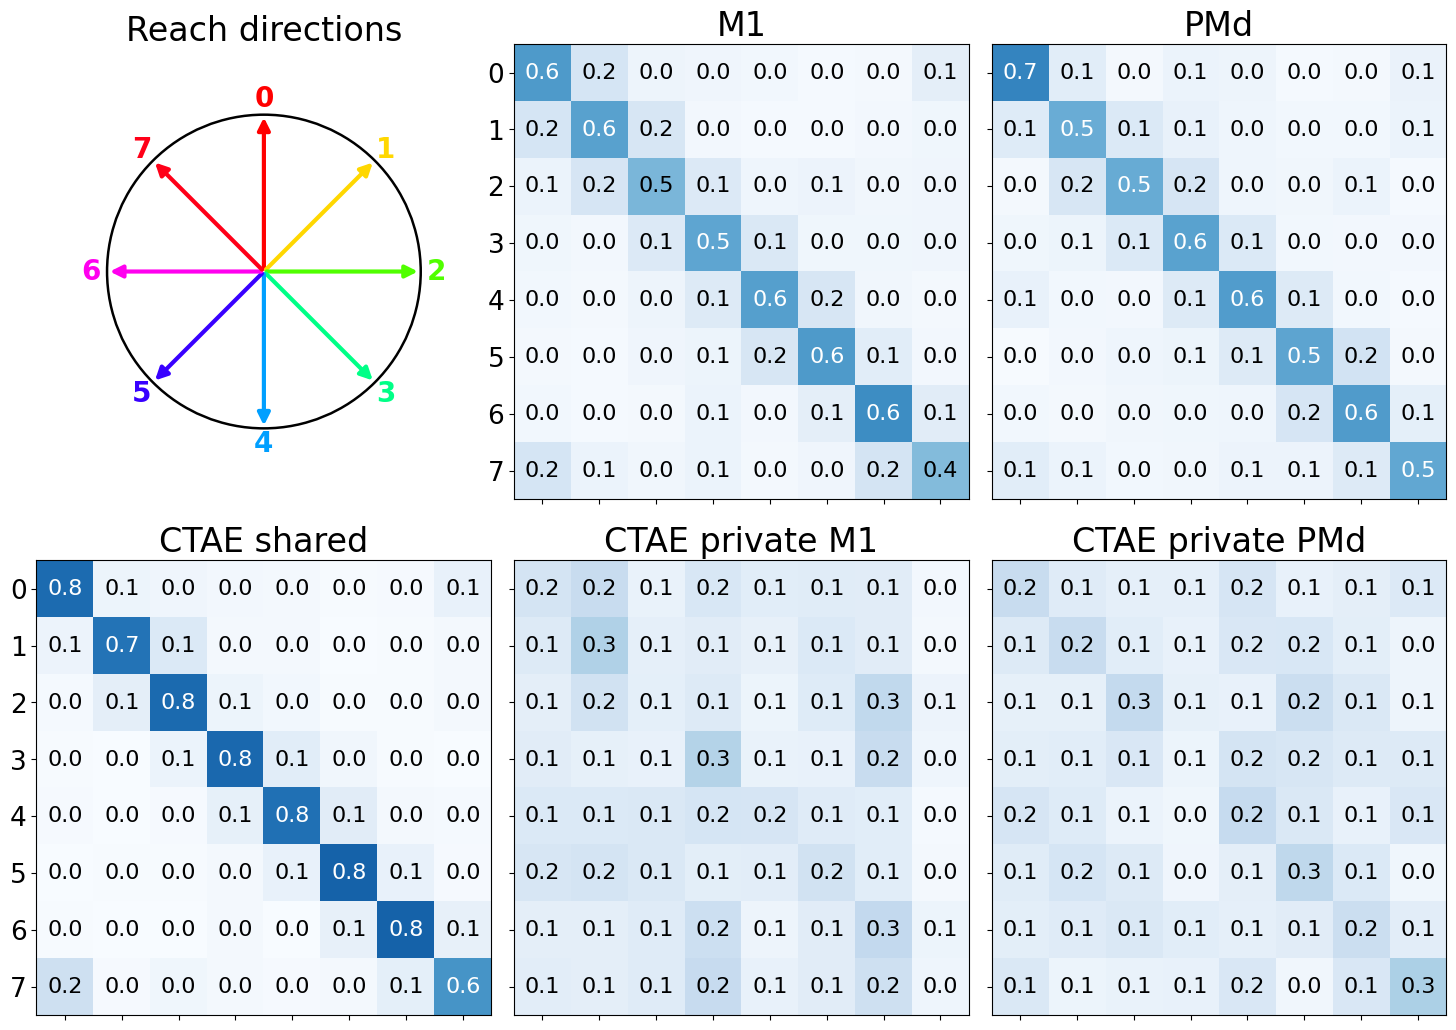

In [11]:
import matplotlib.cm as cm

plot_variables = ["Y_all"]+["Y_pred_all"]*5
plot_data_names = ["data1","data1","data2","shared","region_specific_m1","region_specific_pmd"]
titles = ["Reach directions", "M1", "PMd", 
          "CTAE shared", "CTAE private M1", "CTAE private PMd"]
plt.figure(figsize=(5*3,5.8*3))

for plot_idx,(plot_variable,data_name,title) in enumerate(zip(plot_variables,plot_data_names,titles)):
    decode = "condition"
    
    if plot_idx == 0:
        ax = plt.subplot(3, 3, plot_idx+1)
        ax.set_aspect('equal', 'box')

        # draw the circle
        R = 1.0
        circle = plt.Circle((0, 0), R, facecolor='none', edgecolor='black', lw=1.8)
        ax.add_patch(circle)

        # 8 directions: 0 at up, then clockwise every 45°
        n_levels = 8
        cmap = cm.get_cmap('hsv', n_levels)
        for k in range(n_levels):
            theta = np.deg2rad(90 - 45 * k)  # 0→up, clockwise
            x, y = R*np.cos(theta), R*np.sin(theta)

            # arrow from center to rim
            ax.annotate(
                "", xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", lw=3,
                                mutation_scale=18, color=cmap(k/n_levels))
            )


            ax.text(1.10*x, 1.10*y, str(k),
                    ha='center', va='center',
                    fontsize=20, weight='bold',
                    color=cmap(k/n_levels))

        m = 1.45  
        ax.set_xlim(-m*R, m*R)
        ax.set_ylim(-m*R, m*R)
        ax.axis('off')
        ax.set_title(title, fontsize=24, y=0.99)


    else:    

        y_pred = reconstruction_dict_CTAE[data_name][decode]["Y_pred_all"]       # (trials, T, 2)
        y_true = reconstruction_dict_CTAE[data_name][decode]["Y_all"]

        labels = np.unique(np.concatenate([y_true, y_pred])).astype(int)   # keeps natural order
        # Normalise rows so each row sums to 1  → entries are probabilities
        cm = confusion_matrix(
                 y_true.flatten(), y_pred.flatten(),
                 labels=labels,
                 normalize='true'       # row-wise normalisation
             )

        ax = plt.subplot(3,3,plot_idx+1)
        im = plt.imshow(cm, cmap='Blues', vmin=0, vmax=1)


        for (i, j), p in np.ndenumerate(cm):
            plt.text(j, i, f'{p:.1f}',
                    ha='center', va='center',
                    color='white' if p > 0.5 else 'black', fontsize=16)

        plt.xticks(labels,labels=[""]*len(labels),fontsize=19)

        if (plot_idx+6)%3==0:
            plt.yticks(np.arange(len(labels)),fontsize=19)
        elif plot_idx==1:
            plt.yticks(np.arange(len(labels)),fontsize=19)
        else:
            plt.yticks(np.arange(len(labels)),labels=[""]*len(labels),fontsize=19)


        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
        plt.title(f"{title}",fontsize=24)
        

        

plt.subplots_adjust(left=0.03, right=0.97,wspace=0.05, bottom=0.06, top=0.95, hspace=0.0)

plt.show()


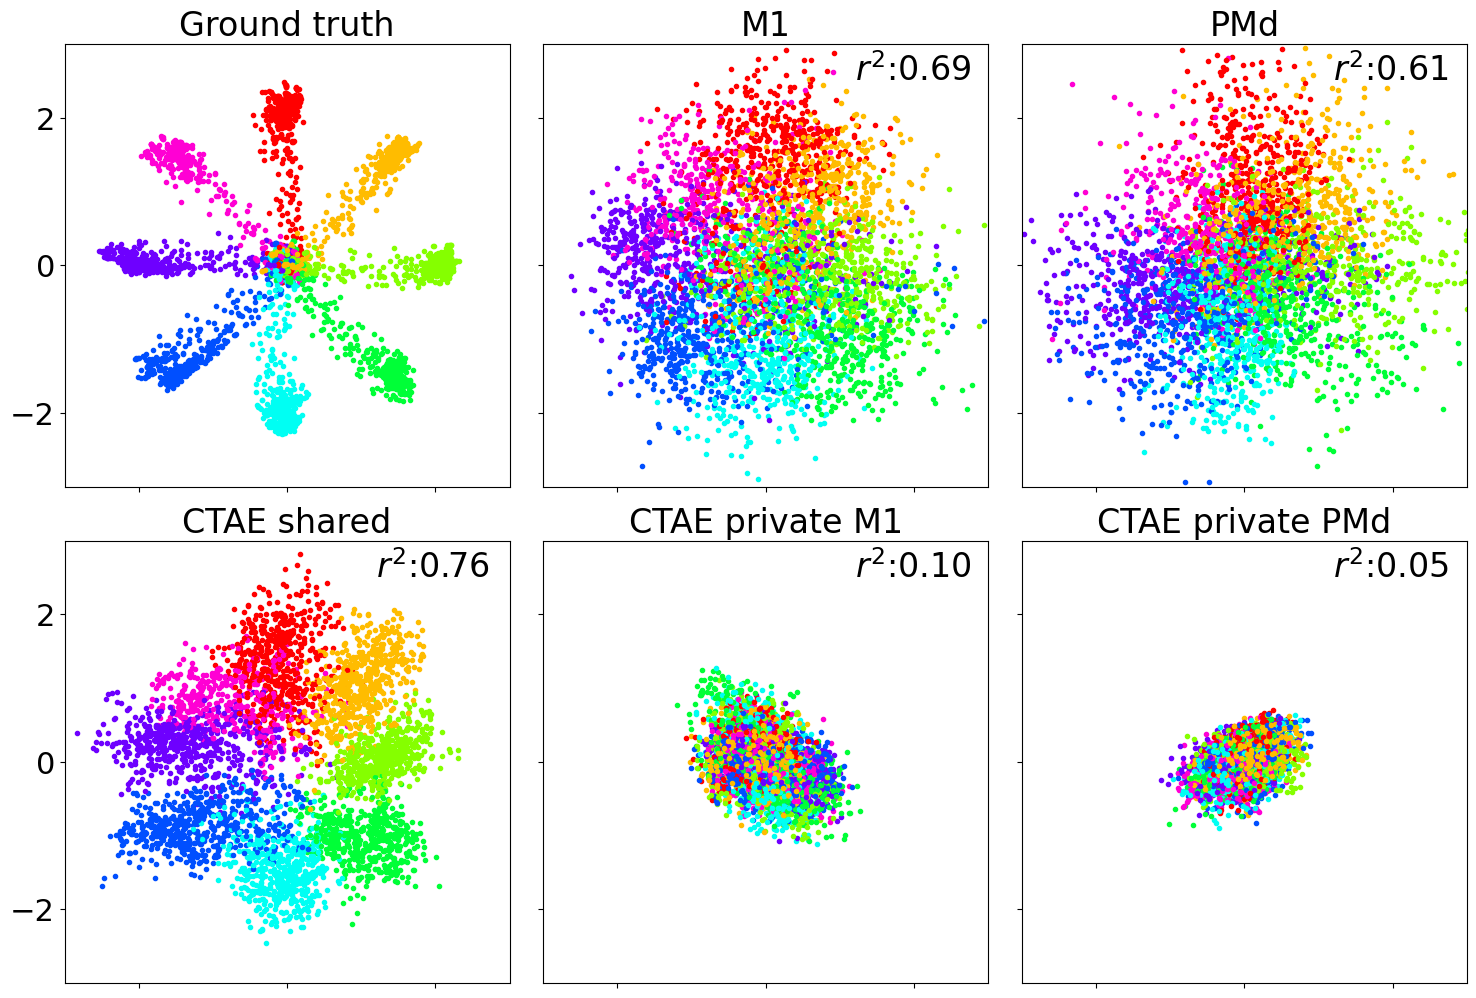

In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

plot_variables = ["Y"]+["Y_pred"]*5
plot_data_names = ["data1","data1","data2","shared","region_specific_m1","region_specific_pmd"]
titles = ["Ground truth", "M1", "PMd", 
          "CTAE shared", "CTAE private M1", "CTAE private PMd"]

plt.figure(figsize=(5*3,5*3))

for plot_idx,(plot_variable,data_name,title) in enumerate(zip(plot_variables,plot_data_names,titles)):

    decode = "position"
    temp1 = reconstruction_dict_CTAE[data_name][decode][plot_variable]       # (trials, T, 2)
    condition = reconstruction_dict_CTAE[data_name][decode]["condition"][:, 0]  # (trials,)
    r2_overall = reconstruction_dict_CTAE[data_name][decode]["r2_overall"]
    
    y_true = reconstruction_dict_CTAE[data_name][decode]["Y"] 
    n_trials,  n_times, n_latents = y_true.shape

    n_pred = 2
    Y_flat = reconstruction_dict_CTAE[data_name][decode]["Y_flat"] 
    Y_pred_flat = reconstruction_dict_CTAE[data_name][decode]["Yp_flat"] 
    Y_true_1 = Y_flat.reshape(n_trials,  n_times, n_pred).transpose(0,2,1).reshape(n_trials*n_pred,n_times)
    Y_pred_1 = Y_pred_flat.reshape(n_trials,  n_times, n_pred).transpose(0,2,1).reshape(n_trials*n_pred,n_times)

    mse_time = np.sqrt(np.mean((Y_true_1-Y_pred_1)**2))

    n_levels   = 9                          
    cmap       = matplotlib.colormaps.get_cmap('hsv').resampled(n_levels)
    norm_cond  = condition % n_levels       

    plt.subplot(3,3,plot_idx+1)
    for trial_id in range(temp1.shape[0]):
        color = cmap(norm_cond[trial_id] / n_levels)  # normalize to 0-1
        plt.plot(temp1[trial_id, :, 0], temp1[trial_id, :, 1], '.', color=color)
    plt.title(title,fontsize=24)
    if plot_idx!=0:
        plt.text(1.2,2.5,s=f"$r^2$:{r2_overall:.2f}",fontsize=24)


    plt.xlim([-3,3])
    plt.ylim([-3,3])
    
    if plot_idx//3==2:
        plt.xticks([-2,0,2],fontsize=22)
    else:
        plt.xticks([-2,0,2],labels=[""]*3,fontsize=22)
        
    if plot_idx%3==0:
        plt.yticks([-2,0,2],fontsize=22)
    else:
        plt.yticks([-2,0,2],labels=[""]*3,fontsize=22)


    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], color=cmap(i / n_levels), lw=2, label=f'{i}')
               for i in range(n_levels)]

plt.tight_layout()
plt.show()
